# 02 — PageRank: implementacija i validacija

Druga sveska u nizu (`01` → `07`). Implementiramo **PageRank** [4] iz nule nad *sparse* matricom susedstva, i validiramo implementaciju poređenjem sa `networkx.pagerank` na istom grafu.

Napomena o ID-jevima čvorova: **web-Stanford** dataset ne sadrži URL-ove stranica, samo anonimizovane numeričke ID-jeve — zato u tabelama "top-N čvorova" vidimo brojeve, ne imena stranica. To ne smeta cilju projekta (poređenje *rangiranja* algoritama međusobno), samo napominjemo da rezultati nisu semantički interpretabilni na nivou pojedinačne stranice.

In [1]:
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
SLIKE_DIR = PROJECT_ROOT / "slike"
SLIKE_DIR.mkdir(parents=True, exist_ok=True)


def save_fig(fig, name, dpi=150):
    """Snima figuru u slike/<name> (koriste se kasnije u dokumentaciji/prezentaciji)."""
    path = SLIKE_DIR / name
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"Sačuvano: {path.relative_to(PROJECT_ROOT)}")


# --- Ista paleta/stil kao u 01_priprema_i_analiza_podataka.ipynb (konzistentno kroz projekat) ---
PALETTE = {
    "pagerank": "#2a78d6", "hits": "#eb6834", "salsa": "#1baf7a", "baseline": "#eda100",
}
INK, INK_2, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, AXIS, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": AXIS, "axes.labelcolor": INK_2,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "text.color": INK, "xtick.color": INK_MUTED, "ytick.color": INK_MUTED,
    "font.size": 11, "axes.spines.top": False, "axes.spines.right": False,
})

# --- Učitavanje grafa obrađenog u 01_priprema_i_analiza_podataka.ipynb ---
A = sp.load_npz(DATA_PROCESSED / "web-stanford_adjacency.npz")
nodes = np.load(DATA_PROCESSED / "web-stanford_nodes.npy")
n = A.shape[0]
print(f"Graf učitan: {n:,} čvorova, {A.nnz:,} grana")

Graf učitan: 281,903 čvorova, 2,312,497 grana


## 1. Teorija — PageRank

PageRank [4] modeluje "slučajnog šetača" (random surfer) koji sa verovatnoćom $d$ (damping faktor) prati slučajno izabranu izlaznu granu trenutne stranice, a sa verovatnoćom $1-d$ "teleportuje" se na potpuno slučajnu stranicu u grafu. Skor stranice $u$ je stacionarna verovatnoća da se šetač u datom trenutku nalazi na $u$:

$$R(u) = \frac{1-d}{n} + d \sum_{v:\, (v,u) \in E} \frac{R(v)}{\text{outdeg}(v)}$$

Koristimo standardnu vrednost **d = 0,85** (Page, Brin, Motwani, Winograd 1998; isti default koriste i `networkx`, i implicitno referentni Najork rad).

**"Dangling" čvorovi** (out-degree = 0, u našem grafu 172 komada — videti `01_priprema_i_analiza_podataka.ipynb`) nemaju kome da "prenesu" svoj skor. Standardno rešenje (koje ovde primenjujemo): njihova masa se ravnomerno redistribuira na SVE čvorove u grafu, kao da imaju granu ka svakom čvoru — ovo garantuje da ukupna masa $\sum_u R(u) = 1$ ostane očuvana kroz iteracije.

In [2]:
def pagerank(A, d=0.85, tol=1e-10, max_iter=200):
    """PageRank preko power-iteracije nad sparse matricom susedstva A (A[i, j] = 1 ako i -> j).

    Vraća (r, history, broj_iteracija) gde je r vektor skorova, a history L1-norma
    promene po iteraciji (koristi se za grafik konvergencije).
    """
    n = A.shape[0]
    out_degree = np.asarray(A.sum(axis=1)).flatten()
    dangling = out_degree == 0

    # normalizuj redove (podeli svaku granu i->j sa outdeg(i)); dangling redovi ostaju nula-redovi
    inv_out = np.zeros(n)
    inv_out[~dangling] = 1.0 / out_degree[~dangling]
    P = sp.diags(inv_out) @ A
    P = P.tocsr()

    r = np.full(n, 1.0 / n)
    history = []
    for it in range(1, max_iter + 1):
        dangling_mass = r[dangling].sum()  # masa "zaglavljena" na dangling čvorovima
        r_new = d * (P.T @ r) + d * dangling_mass / n + (1 - d) / n
        diff = float(np.abs(r_new - r).sum())
        history.append(diff)
        r = r_new
        if diff < tol:
            break
    return r, history, it

## 2. Pokretanje algoritma

In [3]:
pagerank_scores, pr_history, pr_iters = pagerank(A, d=0.85)

print(f"Konvergirao nakon {pr_iters} iteracija")
print(f"Kontrola: zbir svih skorova = {pagerank_scores.sum():.6f}  (treba da bude ≈ 1.0)")

Konvergirao nakon 118 iteracija
Kontrola: zbir svih skorova = 1.000000  (treba da bude ≈ 1.0)


Sačuvano: slike\f2_pagerank_konvergencija.png


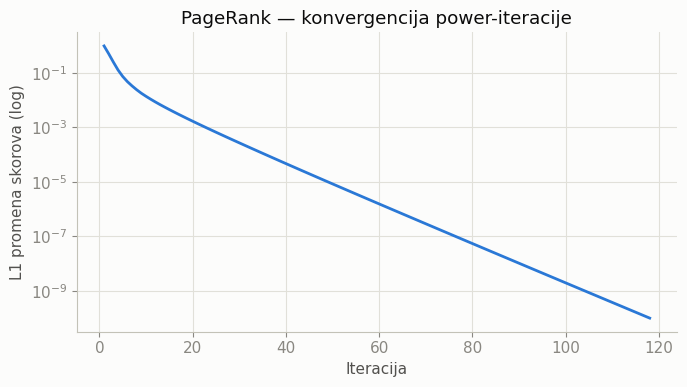

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, len(pr_history) + 1), pr_history, color=PALETTE["pagerank"], linewidth=2)
ax.set_yscale("log")
ax.set_xlabel("Iteracija")
ax.set_ylabel("L1 promena skorova (log)")
ax.set_title("PageRank — konvergencija power-iteracije")
fig.tight_layout()
save_fig(fig, "f2_pagerank_konvergencija.png")
plt.show()

## 3. Top-10 čvorova po PageRank skoru

In [5]:
top10_idx = np.argsort(-pagerank_scores)[:10]
top10_df = pd.DataFrame({
    "rang": range(1, 11),
    "node_id": nodes[top10_idx],
    "pagerank": pagerank_scores[top10_idx],
})
top10_df

,rang,node_id,pagerank
0,1,89073,0.011303
1,2,226411,0.009268
2,3,241454,0.008297
3,4,262860,0.003023
4,5,134832,0.003001
5,6,234704,0.002572
6,7,136821,0.002454
7,8,68889,0.002431
8,9,105607,0.002391
9,10,69358,0.002364


Sačuvano: slike\f2_pagerank_top10.png


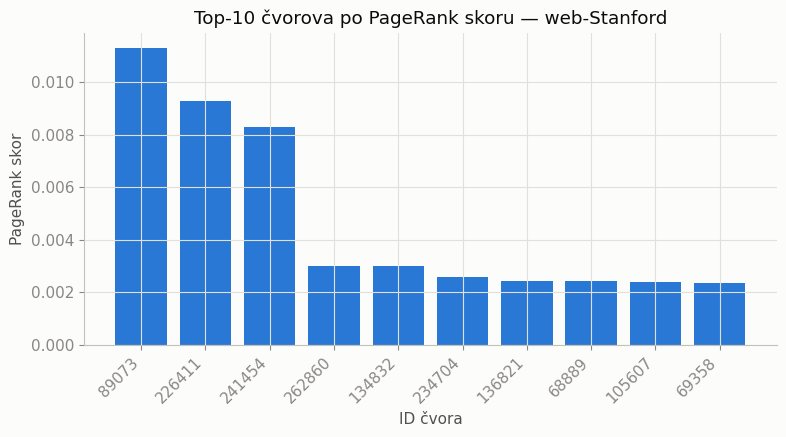

In [6]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(
    [str(v) for v in top10_df["node_id"]], top10_df["pagerank"],
    color=PALETTE["pagerank"],
)
ax.set_xlabel("ID čvora")
ax.set_ylabel("PageRank skor")
ax.set_title("Top-10 čvorova po PageRank skoru — web-Stanford")
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
fig.tight_layout()
save_fig(fig, "f2_pagerank_top10.png")
plt.show()

## 4. Validacija — poređenje sa `networkx.pagerank`

Gradimo `networkx.DiGraph` iz iste sparse matrice (indeksi čvorova ostaju identični, `0..n-1`) i pokrećemo ugrađeni `nx.pagerank` sa istim parametrima ($d=0,85$). Poredimo:

- maksimalnu apsolutnu razliku skorova,
- Spearman-ovu korelaciju rangova,
- top-10 skup čvorova.

In [7]:
import time
import networkx as nx
from scipy.stats import spearmanr

t0 = time.time()
G_nx = nx.from_scipy_sparse_array(A, create_using=nx.DiGraph)
pr_nx_dict = nx.pagerank(G_nx, alpha=0.85, tol=1e-10)
t_nx = time.time() - t0

pagerank_nx = np.array([pr_nx_dict[i] for i in range(n)])

t0 = time.time()
_ = pagerank(A, d=0.85)
t_ours = time.time() - t0

max_abs_diff = np.abs(pagerank_scores - pagerank_nx).max()
rho, _ = spearmanr(pagerank_scores, pagerank_nx)
top10_nx = set(np.argsort(-pagerank_nx)[:10])
top10_overlap = len(top10_nx & set(top10_idx)) / 10

print(f"Max apsolutna razlika skorova: {max_abs_diff:.2e}")
print(f"Spearman korelacija rangova:   {rho:.6f}")
print(f"Preklapanje top-10 skupova:    {top10_overlap:.0%}")
print(f"Vreme (nasa implementacija):   {t_ours:.2f}s")
print(f"Vreme (networkx, uklj. build): {t_nx:.2f}s")

Max apsolutna razlika skorova: 5.85e-07
Spearman korelacija rangova:   0.999997
Preklapanje top-10 skupova:    100%
Vreme (nasa implementacija):   1.81s
Vreme (networkx, uklj. build): 20.80s


## 5. Čuvanje rezultata

Skorove čuvamo da ih `05_poredjenje_algoritama.ipynb` učita bez ponovnog računanja.

In [8]:
np.save(DATA_PROCESSED / "pagerank_scores.npy", pagerank_scores)
print(f"Sačuvano: {(DATA_PROCESSED / 'pagerank_scores.npy').relative_to(PROJECT_ROOT)}")

Sačuvano: data\processed\pagerank_scores.npy


## Zaključci — Faza 2

**Implementacija je validna.** Naša power-iteracija konvergira nakon **118 iteracija** (tol = 10⁻¹⁰), sa geometrijskom (linearnom na log-skali) brzinom konvergencije, i tačno održava $\sum_u R(u) = 1$ — potvrda da je "dangling" redistribucija ispravno implementirana. U poređenju sa `networkx.pagerank` na istom grafu: maksimalna apsolutna razlika skorova je **5,85 × 10⁻⁷**, Spearman korelacija rangova **0,999997**, a top-10 skupovi se **100% poklapaju**. Sitna numerička razlika je posledica različitih kriterijuma zaustavljanja, ne greške u implementaciji.

**Naša implementacija je ~11× brža** (1,81s naspram 20,80s, uključujući izgradnju `nx.DiGraph`-a) — očekivano, jer radimo direktno nad *sparse* matricom bez opšte-namenske apstrakcije grafa, i koristimo zatvoreni izraz za "dangling" redistribuciju umesto guste uniformne matrice.

**Top-10 rezultat.** Tri čvora (**89073, 226411, 241454**) dominiraju sa skorovima 0,0113 / 0,0093 / 0,0083 — zatim nagli pad na ~0,0024–0,0030 za rangove 4–10. Ovakav "long-tail" oblik je konzistentan sa power-law distribucijom in-degree-a iz `01_priprema_i_analiza_podataka.ipynb` (max in-degree = 38.606). Pošto dataset ne sadrži URL-ove, ne možemo semantički protumačiti *koje* su to stranice — ali za cilj projekta (poređenje algoritama) bitno je da imamo referentno rangiranje sačuvano za `05_poredjenje_algoritama.ipynb`.

**Sledeći korak:** `03_hits.ipynb` — implementacija i validacija HITS-a nad istim grafom; posebno pratimo hoće li HITS-ova mutual-reinforcement power-iteracija "ugasiti" čvorove van najveće komponente povezanosti (90,6% grafa — videti Fazu 1).
